# SGHMC & Cyclical SGMCMC

Momentum-based MCMC sampling for posterior inference.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.models import MLP
from deepuq.methods.mcmc import SGHMCOptimizer, CyclicalSGMCMC

## Generate Data

In [2]:
np.random.seed(42)
x_train = np.random.uniform(-3, 3, 100).astype(np.float32)
y_train = (np.sin(x_train) + np.random.normal(0, 0.1, 100)).astype(np.float32)
x_test = np.linspace(-5, 5, 200).astype(np.float32)

x_train_t = torch.from_numpy(x_train).unsqueeze(-1)
y_train_t = torch.from_numpy(y_train).unsqueeze(-1)
x_test_t = torch.from_numpy(x_test).unsqueeze(-1)

## SGHMC Sampling

In [3]:
# Create and pre-train model
model = MLP(1, [32, 32], 1)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = torch.nn.MSELoss()

for epoch in range(100):
    optimizer.zero_grad()
    loss = loss_fn(model(x_train_t), y_train_t)
    loss.backward()
    optimizer.step()

print(f"Pre-training loss: {loss.item():.4f}")

# SGHMC sampling - SGHMCOptimizer takes params iterator
sghmc = SGHMCOptimizer(model.parameters(), lr=1e-3, momentum_decay=0.01, noise_scale=0.1)
samples = []

for step in range(200):
    sghmc.zero_grad()
    loss = loss_fn(model(x_train_t), y_train_t)
    loss.backward()
    sghmc.step()
    if step >= 0 and step % 10 == 0:
        samples.append({k: v.clone() for k, v in model.state_dict().items()})

print(f"Collected {len(samples)} samples")

Pre-training loss: 0.0082
Collected 20 samples


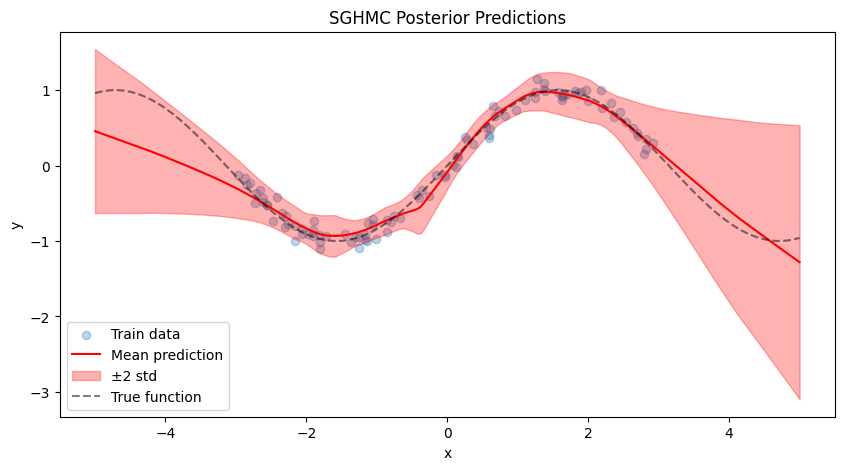

In [4]:
# Predict with posterior samples
preds = []
for sample in samples:
    model.load_state_dict(sample)
    with torch.no_grad():
        preds.append(model(x_test_t).numpy())

preds = np.array(preds).squeeze()
mean = preds.mean(axis=0)
std = preds.std(axis=0)

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.3, label="Train data")
plt.plot(x_test, mean, "r-", label="Mean prediction")
plt.fill_between(x_test, mean - 2*std, mean + 2*std, alpha=0.3, color="red", label="±2 std")
plt.plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
plt.legend()
plt.title("SGHMC Posterior Predictions")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

## Cyclical SGMCMC

Collected 12 samples from cyclical schedule


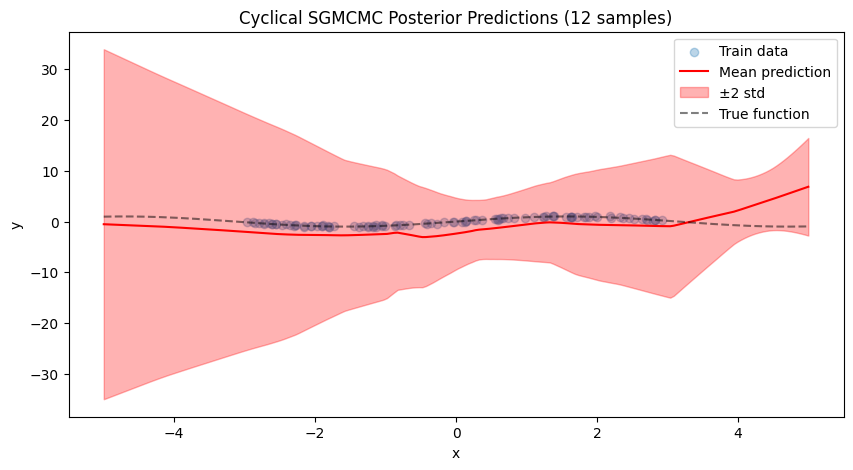

In [5]:
# Re-initialize model
model = MLP(1, [32, 32], 1)

# Pre-train
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
for epoch in range(100):
    optimizer.zero_grad()
    loss = loss_fn(model(x_train_t), y_train_t)
    loss.backward()
    optimizer.step()

# Cyclical SGMCMC - constructor: (model, base_optimizer_cls, cycle_length, n_cycles, samples_per_cycle)
cyclical = CyclicalSGMCMC(
    model, SGHMCOptimizer, cycle_length=50, n_cycles=4, samples_per_cycle=3
)

train_data = torch.utils.data.TensorDataset(x_train_t, y_train_t)
train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)

cyclical_samples = cyclical.run(train_loader, loss_fn)
print(f"Collected {len(cyclical_samples)} samples from cyclical schedule")

# Predict
preds = []
for sample in cyclical_samples:
    model.load_state_dict(sample)
    with torch.no_grad():
        preds.append(model(x_test_t).numpy())

preds = np.array(preds).squeeze()
mean = preds.mean(axis=0)
std = preds.std(axis=0)

plt.figure(figsize=(10, 5))
plt.scatter(x_train, y_train, alpha=0.3, label="Train data")
plt.plot(x_test, mean, "r-", label="Mean prediction")
plt.fill_between(x_test, mean - 2*std, mean + 2*std, alpha=0.3, color="red", label="\u00b12 std")
plt.plot(x_test, np.sin(x_test), "k--", alpha=0.5, label="True function")
plt.legend()
plt.title("Cyclical SGMCMC Posterior Predictions (12 samples)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()